In [1]:
import os
import json
import pandas as pd
from typing import List

In [8]:
def load_parametres(subdir: str, filenames: List[str]) -> pd.DataFrame:
    rows = []
    for filename in filenames:
        path = f"{subdir}/{filename}"
        if os.path.exists(path):
            with open(path, 'r') as file:
                try:
                    data = json.load(file)
                except:
                    print(path)
        else:
            print(path)
            continue
        row = {}
        row['batch_size'] = data['data_size']
        row['num_microbatches'] = data['data_size'] // data['batch_size']
        row['prompt_len'] = data['max_prompt_len']
        row['new_tokens'] = data['max_new_tokens']
        row['time (s)'] = data['inference_time']
        row['throughput (tokens/s)'] = data['throughput']
        row['peak memory GPU:0'], row['peak memory GPU:1'] = data['max_memory_allocated_per_device']
        rows.append(row)
        
        
    return pd.DataFrame(rows)

filenames = []
for batch_size in range(8, 64 + 1, 8):
    for max_prompt_len in range(16, 128 + 1, 16):
        filename = f"batch_size={batch_size}-max_prompt_len={max_prompt_len}deverta_stats.json"
        filenames.append(filename)

df = load_parametres('src/results/deberta/pipeline_1', filenames)         
        

In [9]:
df.to_csv('deberta_pipeline_1.csv')

# Analyse

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:
df_1 = pd.read_csv("opt_pipeline_1.csv")
df_2 = pd.read_csv("opt_pipeline_2.csv")

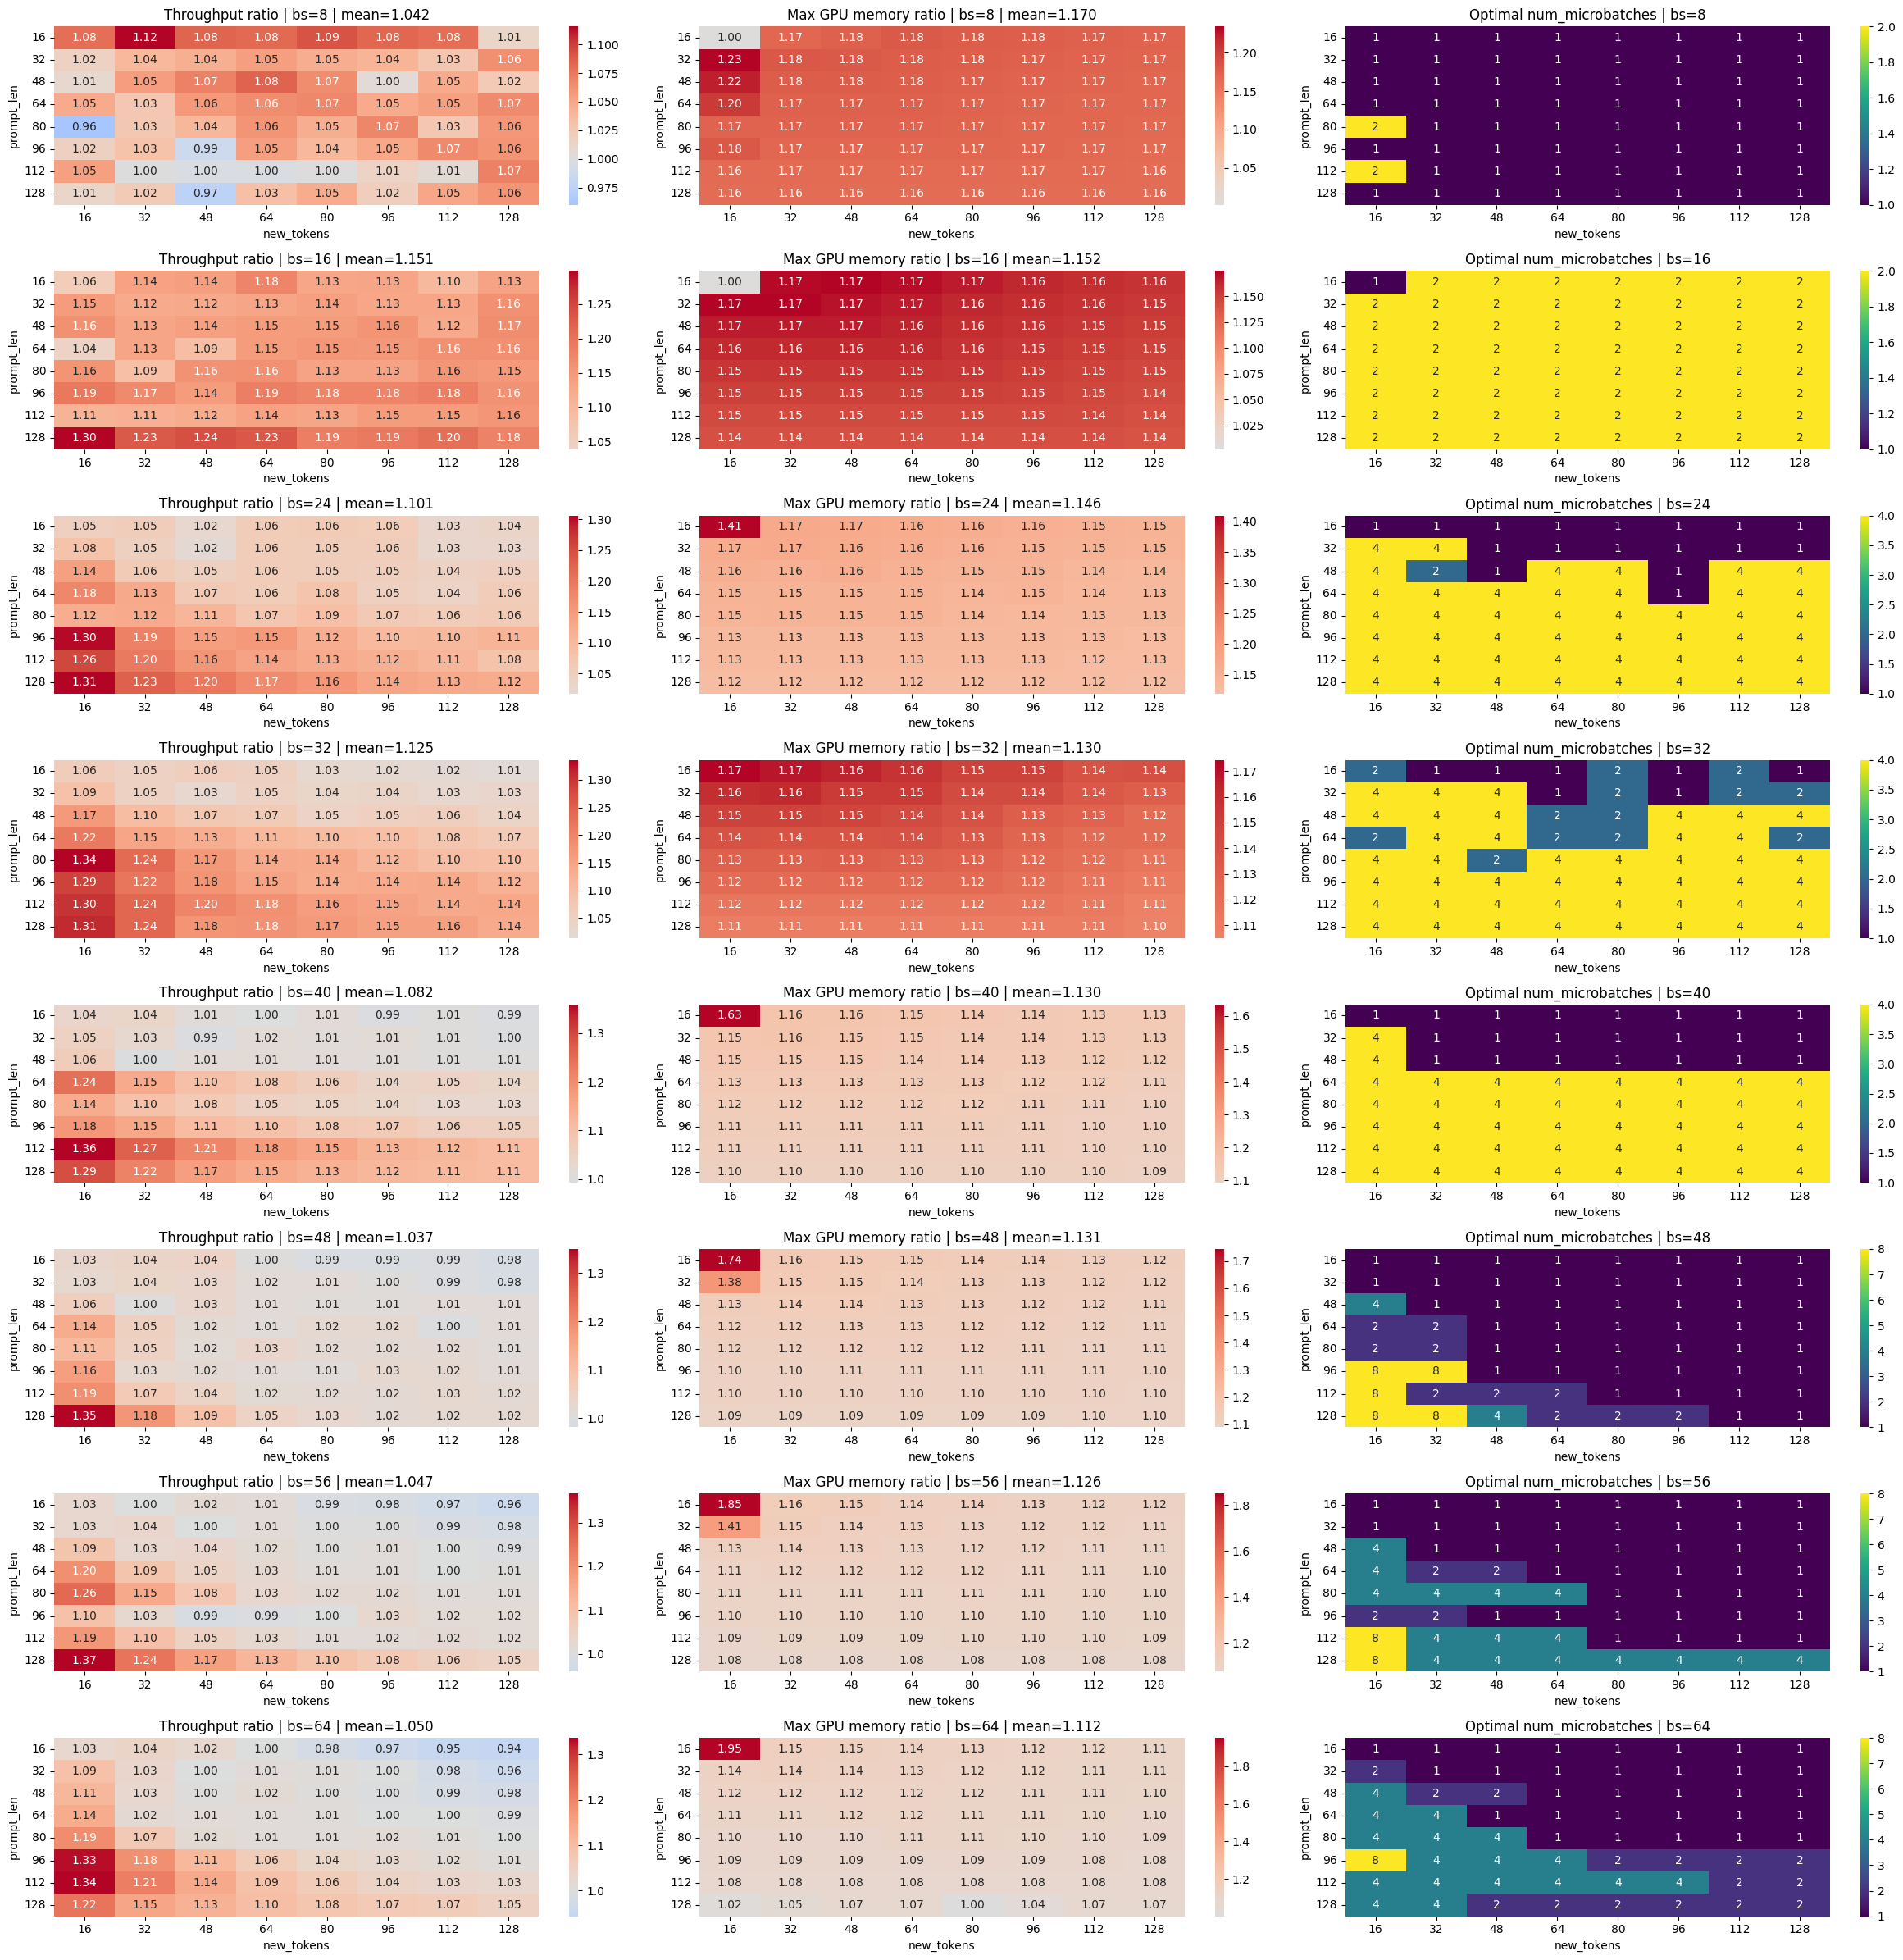

In [50]:
batch_sizes = range(8, 64 + 1, 8)

fig, axes = plt.subplots(len(batch_sizes), 3, figsize=(24, 3 * len(batch_sizes)))

if len(batch_sizes) == 1:
    axes = [axes]

for i, batch_size in enumerate(batch_sizes):

    # ======================
    # DF1
    # ======================
    data1 = df_1[df_1['batch_size'] == batch_size].copy()
    data1['max_gpu'] = data1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

    pivot1_thr = data1.pivot_table(
        values='throughput (tokens/s)',
        index='prompt_len',
        columns='new_tokens'
    )

    pivot1_mem = data1.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )

    # ======================
    # DF2 (берём лучший throughput)
    # ======================
    data2 = df_2[df_2['batch_size'] == batch_size].copy()
    best_idx = data2.groupby(['prompt_len', 'new_tokens'])['throughput (tokens/s)'].idxmax()
    best_data2 = data2.loc[best_idx].copy()
    best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

    pivot2_thr = best_data2.pivot_table(
        values='throughput (tokens/s)',
        index='prompt_len',
        columns='new_tokens'
    )

    pivot2_mem = best_data2.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )

    pivot_micro = best_data2.pivot_table(
        values='num_microbatches',
        index='prompt_len',
        columns='new_tokens'
    )

    # ======================
    # RATIOS
    # ======================
    ratio_thr = pivot2_thr / pivot1_thr
    ratio_mem = pivot2_mem / pivot1_mem

    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)

    # ======================
    # PLOTS
    # ======================

    # Throughput
    sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 0])
    axes[i, 0].set_title(f"Throughput ratio | bs={batch_size} | mean={mean_ratio_thr:.3f}")
    axes[i, 0].set_xlabel("new_tokens")
    axes[i, 0].set_ylabel("prompt_len")

    # Memory
    sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 1])
    axes[i, 1].set_title(f"Max GPU memory ratio | bs={batch_size} | mean={mean_ratio_mem:.3f}")
    axes[i, 1].set_xlabel("new_tokens")
    axes[i, 1].set_ylabel("prompt_len")

    # Optimal microbatches
    sns.heatmap(pivot_micro, annot=True, fmt=".0f", cmap="viridis", ax=axes[i, 2])
    axes[i, 2].set_title(f"Optimal num_microbatches | bs={batch_size}")
    axes[i, 2].set_xlabel("new_tokens")
    axes[i, 2].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

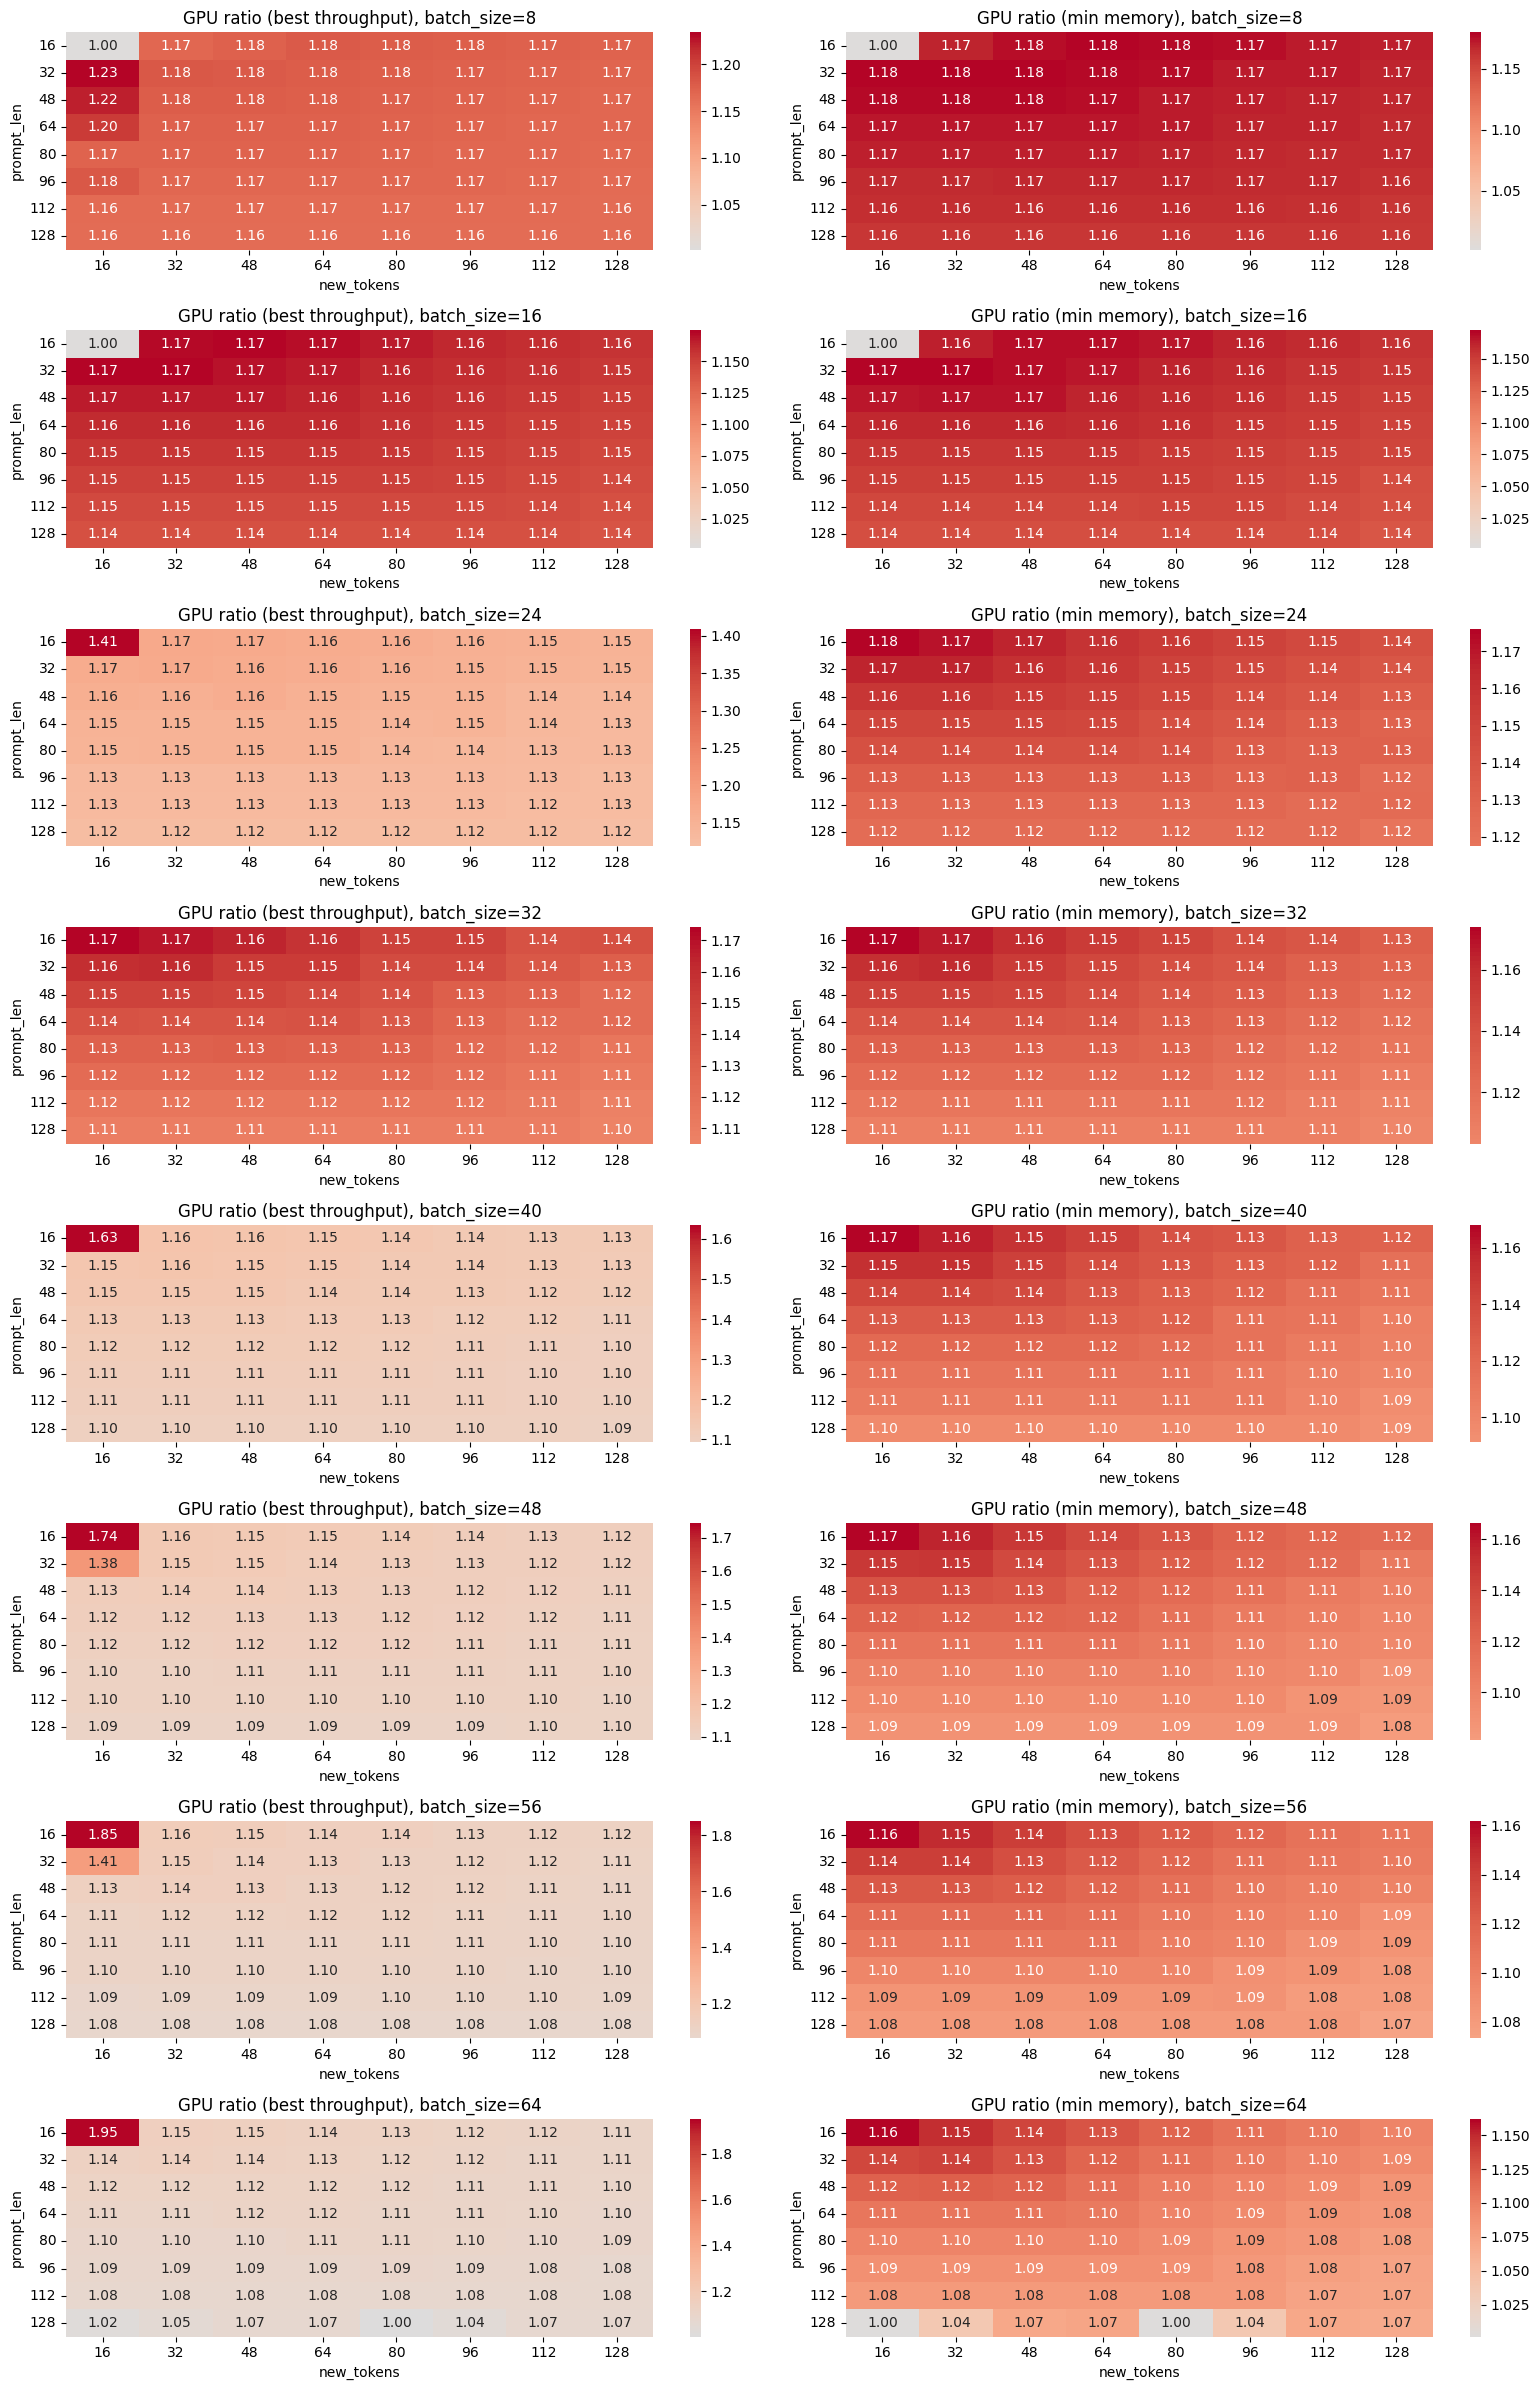

In [38]:
batch_sizes = range(8, 64 + 1, 8)

fig, axes = plt.subplots(len(batch_sizes), 2, figsize=(16, 3 * len(batch_sizes)))

if len(batch_sizes) == 1:
    axes = [axes]

for i, batch_size in enumerate(batch_sizes):

    # ---------------- df_1 ----------------
    data1 = df_1[df_1['batch_size'] == batch_size].copy()
    data1['max_gpu'] = data1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

    pivot1 = data1.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )

    # ---------------- df_2 ----------------
    data2 = df_2[df_2['batch_size'] == batch_size].copy()
    data2['max_gpu'] = data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

    # --- вариант 1: берем конфиг с max throughput ---
    best_idx_thr = data2.groupby(['prompt_len', 'new_tokens'])['throughput (tokens/s)'].idxmax()
    best_thr = data2.loc[best_idx_thr]

    pivot_thr = best_thr.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )

    ratio_thr = pivot_thr / pivot1

    # --- вариант 2: берем конфиг с min GPU memory ---
    best_idx_mem = data2.groupby(['prompt_len', 'new_tokens'])['max_gpu'].idxmin()
    best_mem = data2.loc[best_idx_mem]

    pivot_mem = best_mem.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )

    ratio_mem = pivot_mem / pivot1

    # ---------------- plotting ----------------

    sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 0])
    axes[i, 0].set_title(f"GPU ratio (best throughput), batch_size={batch_size}")
    axes[i, 0].set_xlabel("new_tokens")
    axes[i, 0].set_ylabel("prompt_len")

    sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 1])
    axes[i, 1].set_title(f"GPU ratio (min memory), batch_size={batch_size}")
    axes[i, 1].set_xlabel("new_tokens")
    axes[i, 1].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

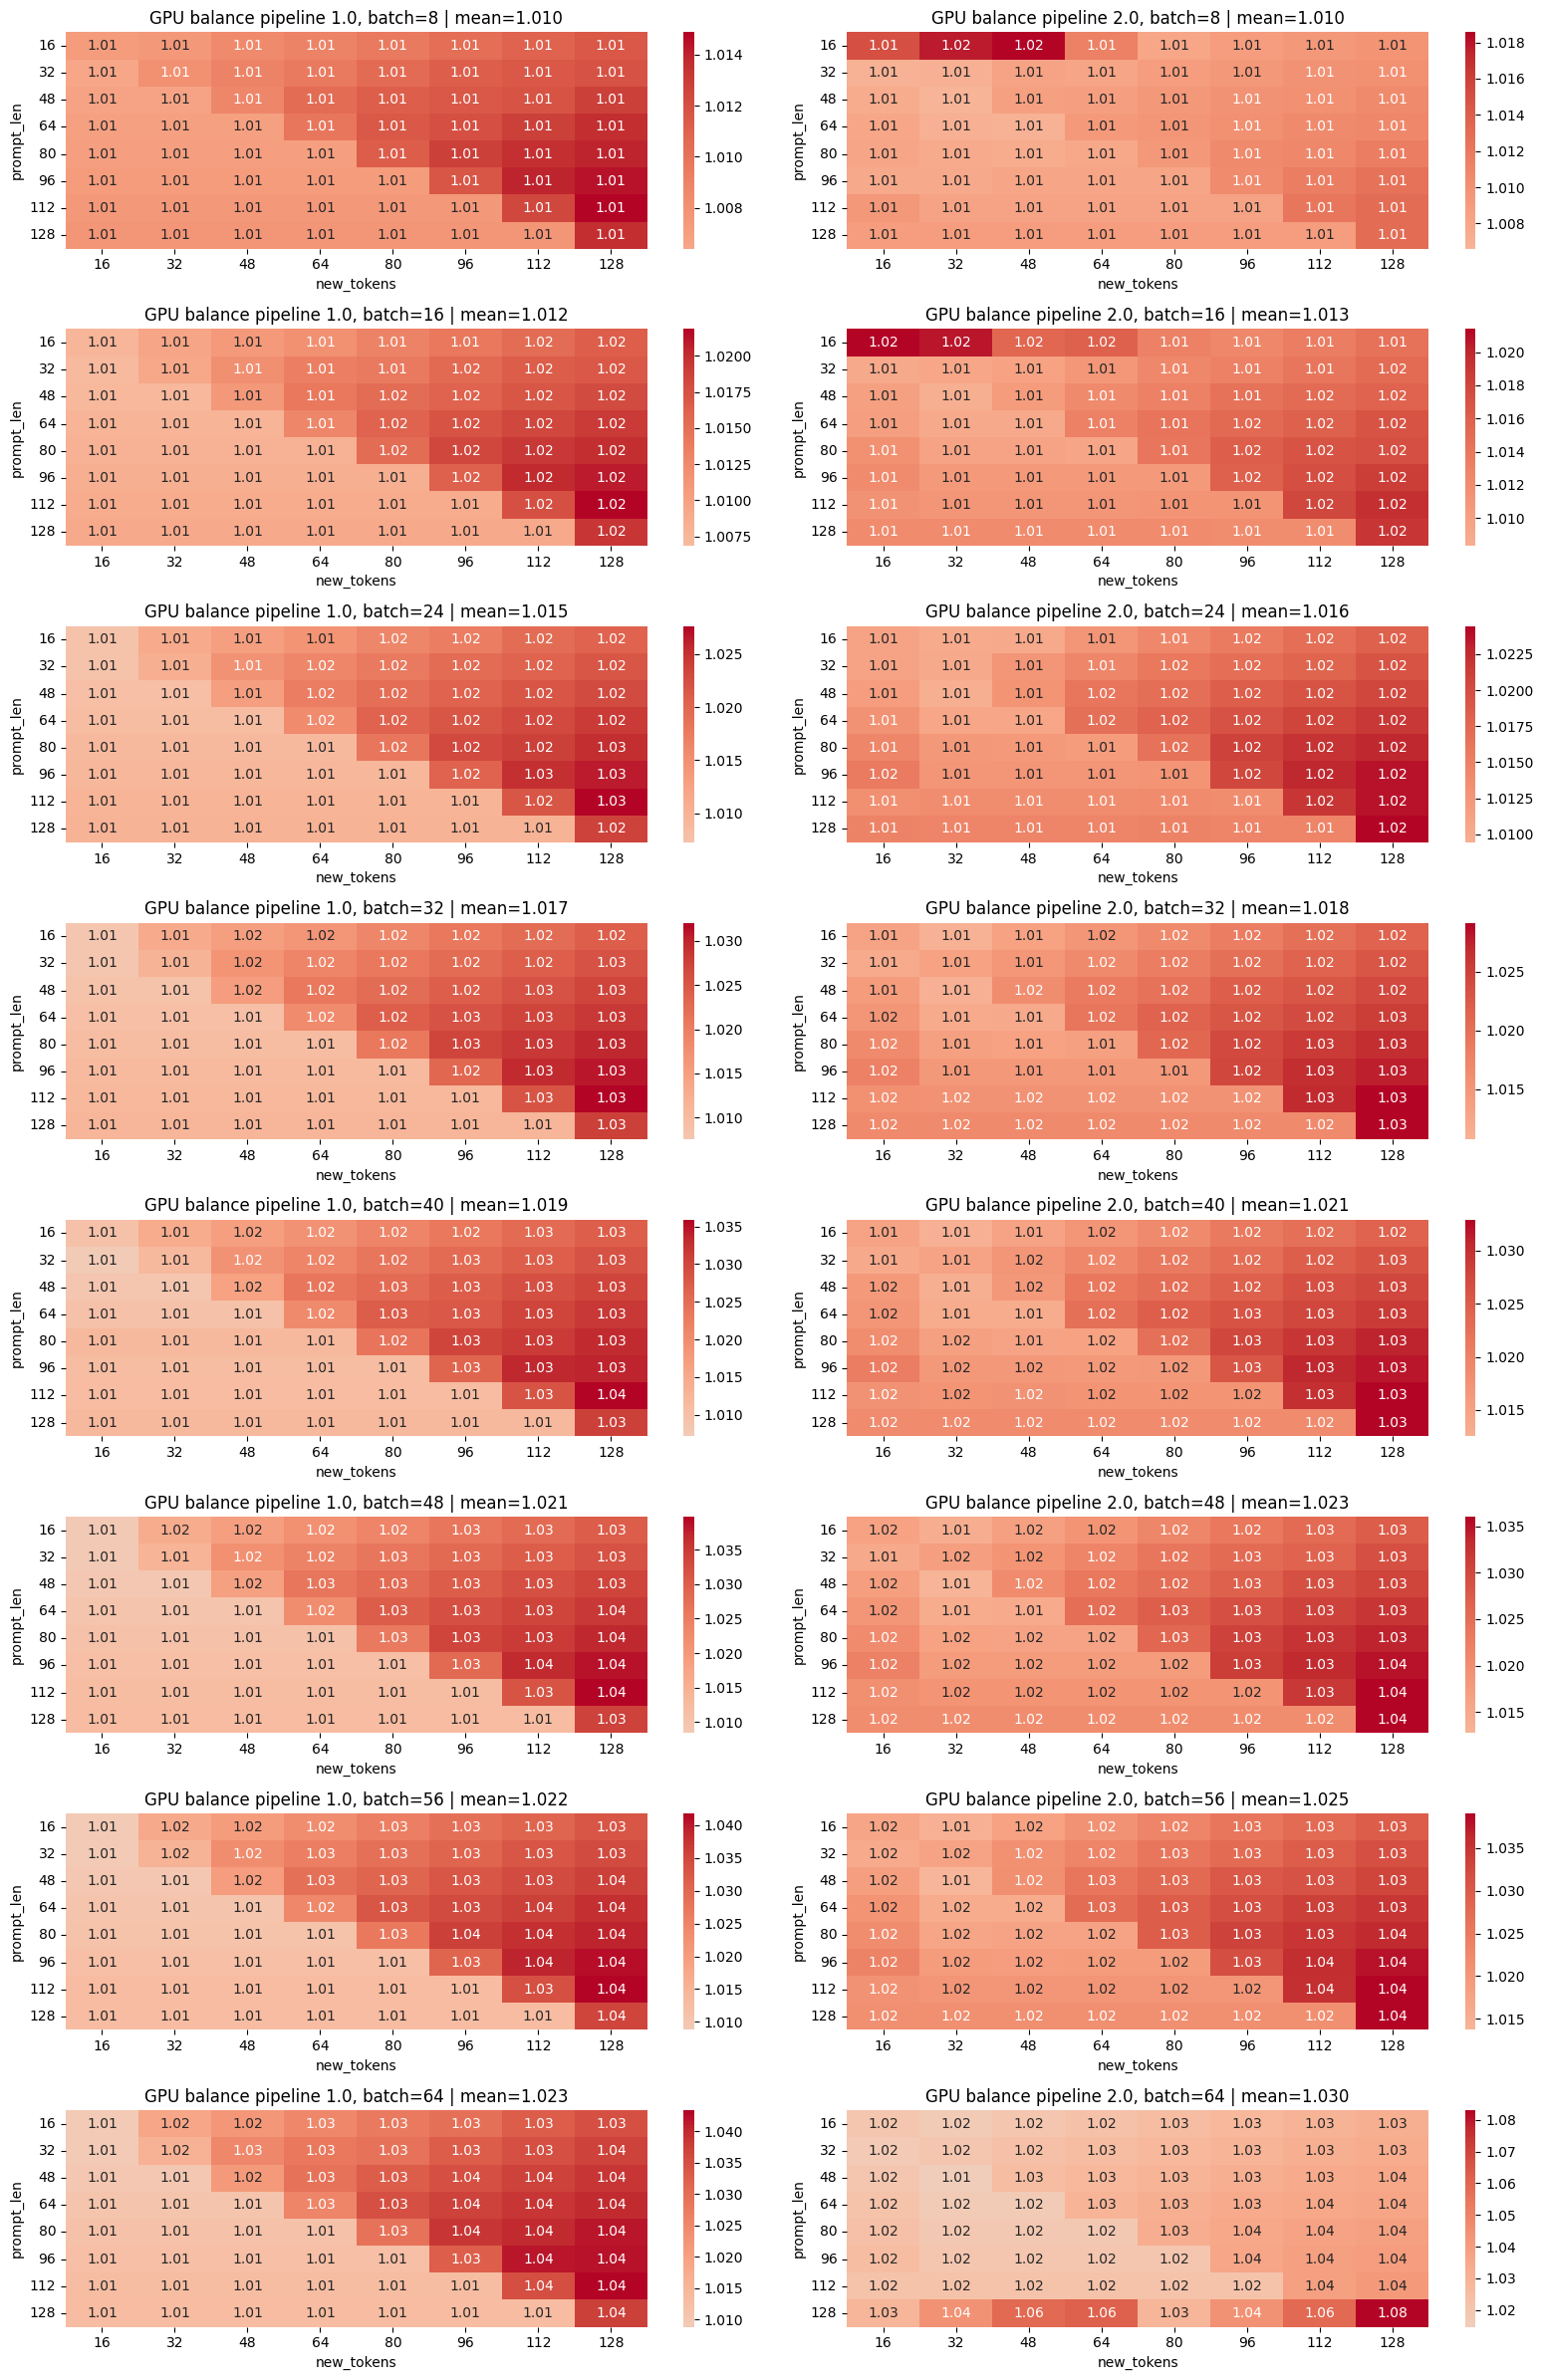

In [48]:
# --- df_1 ---
df1_tmp = df_1.copy()
df1_tmp['gpu_ratio'] = df1_tmp['peak memory GPU:0'] / df1_tmp['peak memory GPU:1']

df1_mean = (
    df1_tmp
    .groupby(['batch_size', 'prompt_len', 'new_tokens'])['gpu_ratio']
    .mean()
    .reset_index()
)

# --- df_2 ---
df2_tmp = df_2.copy()
df2_tmp['gpu_ratio'] = df2_tmp['peak memory GPU:0'] / df2_tmp['peak memory GPU:1']

df2_mean = (
    df2_tmp
    .groupby(['batch_size', 'prompt_len', 'new_tokens'])['gpu_ratio']
    .mean()
    .reset_index()
)

batch_sizes = range(8, 64 + 1, 8)

fig, axes = plt.subplots(len(batch_sizes), 2, figsize=(16, 3 * len(batch_sizes)))

for i, batch_size in enumerate(batch_sizes):

    # --- df_1 ---
    data1 = df1_mean[df1_mean['batch_size'] == batch_size]
    pivot1 = data1.pivot_table(
        values='gpu_ratio',
        index='prompt_len',
        columns='new_tokens'
    )

    mean1 = np.nanmean(pivot1.values)

    sns.heatmap(pivot1, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 0])
    axes[i, 0].set_title(f"GPU balance pipeline 1.0, batch={batch_size} | mean={mean1:.3f}")
    axes[i, 0].set_xlabel("new_tokens")
    axes[i, 0].set_ylabel("prompt_len")

    # --- df_2 ---
    data2 = df2_mean[df2_mean['batch_size'] == batch_size]
    pivot2 = data2.pivot_table(
        values='gpu_ratio',
        index='prompt_len',
        columns='new_tokens'
    )

    mean2 = np.nanmean(pivot2.values)

    sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 1])
    axes[i, 1].set_title(f"GPU balance pipeline 2.0, batch={batch_size} | mean={mean2:.3f}")
    axes[i, 1].set_xlabel("new_tokens")
    axes[i, 1].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

**Задачи:**
1. Провести эксперимент с Deepspeed и transformers
2. провести эксперимент с batch_size = 16, но более большим new_tokens и prompt_len
3. Попытаться провести эксперименты с другими моделями, не только Decoder-only

## prefill stage

In [12]:
df_1 = pd.read_csv("opt_pipeline_1-prefill.csv")
df_2 = pd.read_csv("opt_pipeline_2-prefill.csv")

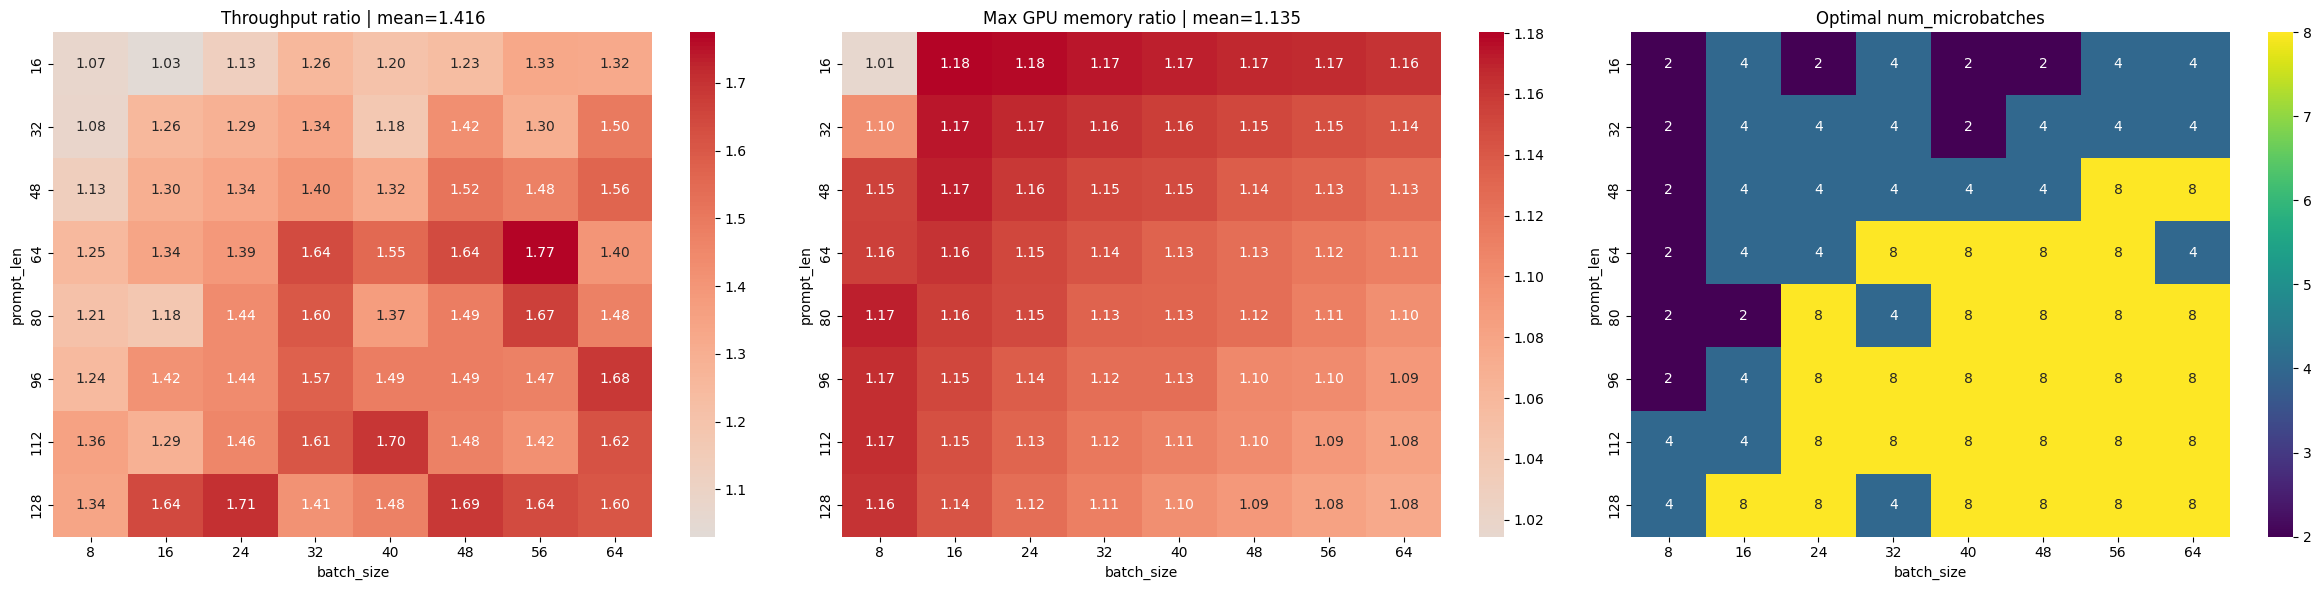

In [17]:


# --- подготовка данных ---
df_1['max_gpu'] = df_1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

best_idx = df_2.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
best_data2 = df_2.loc[best_idx].copy()
best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

# --- pivot tables ---
pivot_thr = best_data2.pivot_table(
    values='throughput (tokens/s)',
    index='prompt_len',
    columns='batch_size'
)
pivot_thr_base = df_1.pivot_table(
    values='throughput (tokens/s)',
    index='prompt_len',
    columns='batch_size'
)

pivot_mem = best_data2.pivot_table(
    values='max_gpu',
    index='prompt_len',
    columns='batch_size'
)
pivot_mem_base = df_1.pivot_table(
    values='max_gpu',
    index='prompt_len',
    columns='batch_size'
)

pivot_micro = best_data2.pivot_table(
    values='num_microbatches',
    index='prompt_len',
    columns='batch_size'
)

# --- ratios ---
ratio_thr = pivot_thr / pivot_thr_base
ratio_mem = pivot_mem / pivot_mem_base

mean_ratio_thr = np.nanmean(ratio_thr.values)
mean_ratio_mem = np.nanmean(ratio_mem.values)

# --- plotting ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[0])
axes[0].set_title(f"Throughput ratio | mean={mean_ratio_thr:.3f}")
axes[0].set_xlabel("batch_size")
axes[0].set_ylabel("prompt_len")

sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title(f"Max GPU memory ratio | mean={mean_ratio_mem:.3f}")
axes[1].set_xlabel("batch_size")
axes[1].set_ylabel("prompt_len")

sns.heatmap(pivot_micro, annot=True, fmt=".0f", cmap="viridis", ax=axes[2])
axes[2].set_title(f"Optimal num_microbatches")
axes[2].set_xlabel("batch_size")
axes[2].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

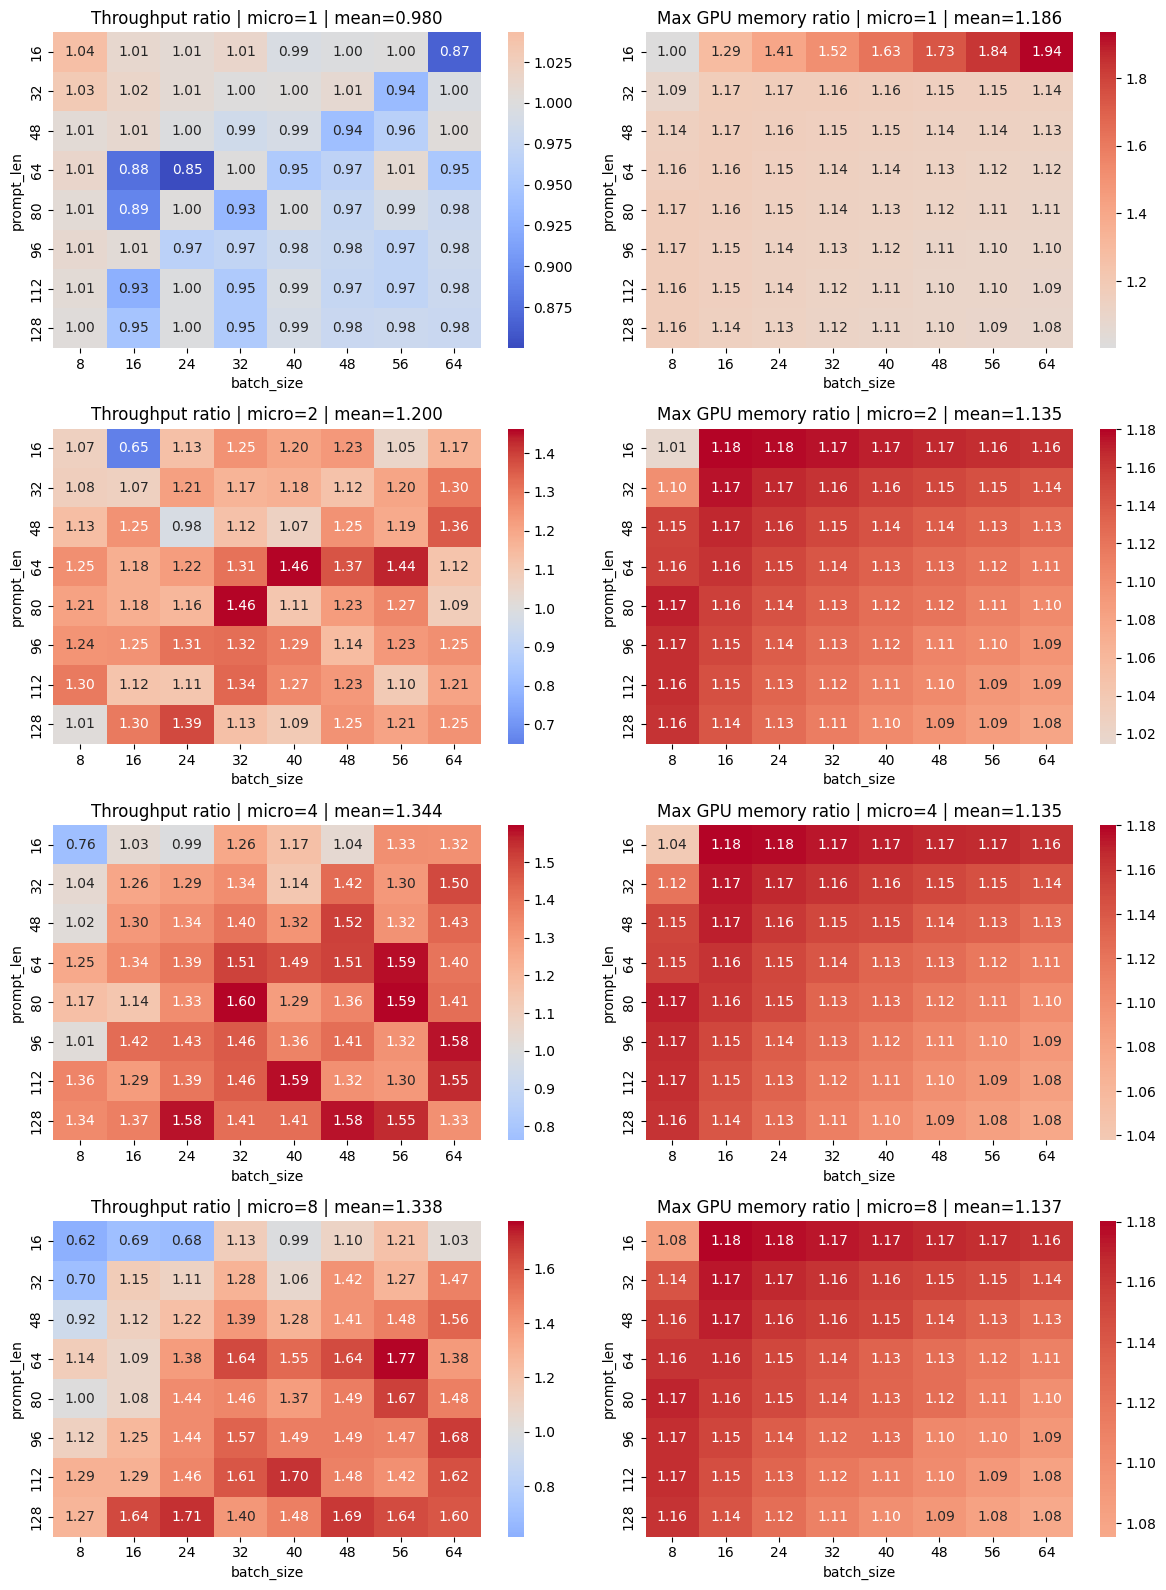

In [27]:
num_microbatches_list = sorted(df_2['num_microbatches'].unique())

# создаём фигуру: N рядов = количество num_microbatches, 2 столбца (Throughput, Memory)
fig, axes = plt.subplots(len(num_microbatches_list), 2, figsize=(12, 4 * len(num_microbatches_list)))

if len(num_microbatches_list) == 1:
    axes = np.array([[axes[0], axes[1]]])  # корректируем на 2D массив axes

for idx, micro in enumerate(num_microbatches_list):
    
    # --- df_2: фиксируем num_microbatches ---
    df2_micro = df_2[df_2['num_microbatches'] == micro].copy()
    best_idx = df2_micro.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
    best_data2 = df2_micro.loc[best_idx].copy()
    best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)
    
    # --- df_1: среднее по всем num_microbatches для каждой комбинации prompt_len и batch_size ---
    df1_group = df_1.groupby(['prompt_len', 'batch_size']).mean().reset_index()
    df1_group['max_gpu'] = df1_group[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)
    
    # --- pivot tables ---
    pivot_thr_df2 = best_data2.pivot_table(values='throughput (tokens/s)', index='prompt_len', columns='batch_size')
    pivot_thr_df1 = df1_group.pivot_table(values='throughput (tokens/s)', index='prompt_len', columns='batch_size')
    
    pivot_mem_df2 = best_data2.pivot_table(values='max_gpu', index='prompt_len', columns='batch_size')
    pivot_mem_df1 = df1_group.pivot_table(values='max_gpu', index='prompt_len', columns='batch_size')
    
    # --- ratios ---
    ratio_thr = pivot_thr_df2 / pivot_thr_df1
    ratio_mem = pivot_mem_df2 / pivot_mem_df1
    
    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)
    
    # --- plotting ---
    sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"Throughput ratio | micro={micro} | mean={mean_ratio_thr:.3f}")
    axes[idx, 0].set_xlabel("batch_size")
    axes[idx, 0].set_ylabel("prompt_len")
    
    sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[idx, 1])
    axes[idx, 1].set_title(f"Max GPU memory ratio | micro={micro} | mean={mean_ratio_mem:.3f}")
    axes[idx, 1].set_xlabel("batch_size")
    axes[idx, 1].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

## Deberta

In [10]:
df_1 = pd.read_csv("deberta_pipeline_1.csv")
df_2 = pd.read_csv("deberta_pipeline_2.csv")

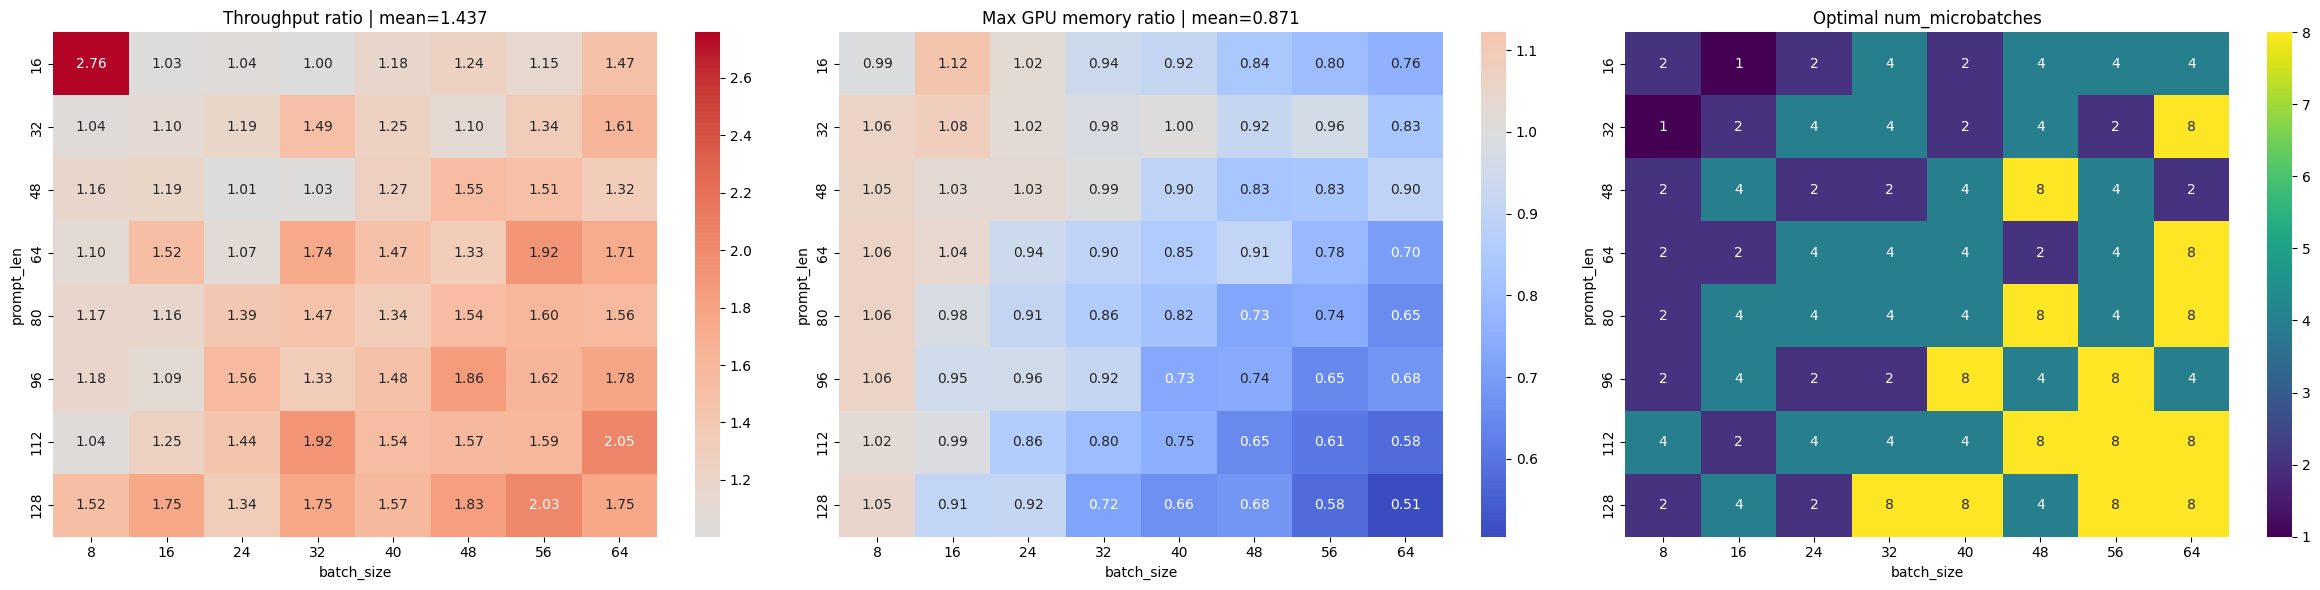

In [13]:


# --- подготовка данных ---
df_1['max_gpu'] = df_1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

best_idx = df_2.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
best_data2 = df_2.loc[best_idx].copy()
best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

# --- pivot tables ---
pivot_thr = best_data2.pivot_table(
    values='throughput (tokens/s)',
    index='prompt_len',
    columns='batch_size'
)
pivot_thr_base = df_1.pivot_table(
    values='throughput (tokens/s)',
    index='prompt_len',
    columns='batch_size'
)

pivot_mem = best_data2.pivot_table(
    values='max_gpu',
    index='prompt_len',
    columns='batch_size'
)
pivot_mem_base = df_1.pivot_table(
    values='max_gpu',
    index='prompt_len',
    columns='batch_size'
)

pivot_micro = best_data2.pivot_table(
    values='num_microbatches',
    index='prompt_len',
    columns='batch_size'
)

# --- ratios ---
ratio_thr = pivot_thr / pivot_thr_base
ratio_mem = pivot_mem / pivot_mem_base

mean_ratio_thr = np.nanmean(ratio_thr.values)
mean_ratio_mem = np.nanmean(ratio_mem.values)

# --- plotting ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[0])
axes[0].set_title(f"Throughput ratio | mean={mean_ratio_thr:.3f}")
axes[0].set_xlabel("batch_size")
axes[0].set_ylabel("prompt_len")

sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title(f"Max GPU memory ratio | mean={mean_ratio_mem:.3f}")
axes[1].set_xlabel("batch_size")
axes[1].set_ylabel("prompt_len")

sns.heatmap(pivot_micro, annot=True, fmt=".0f", cmap="viridis", ax=axes[2])
axes[2].set_title(f"Optimal num_microbatches")
axes[2].set_xlabel("batch_size")
axes[2].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

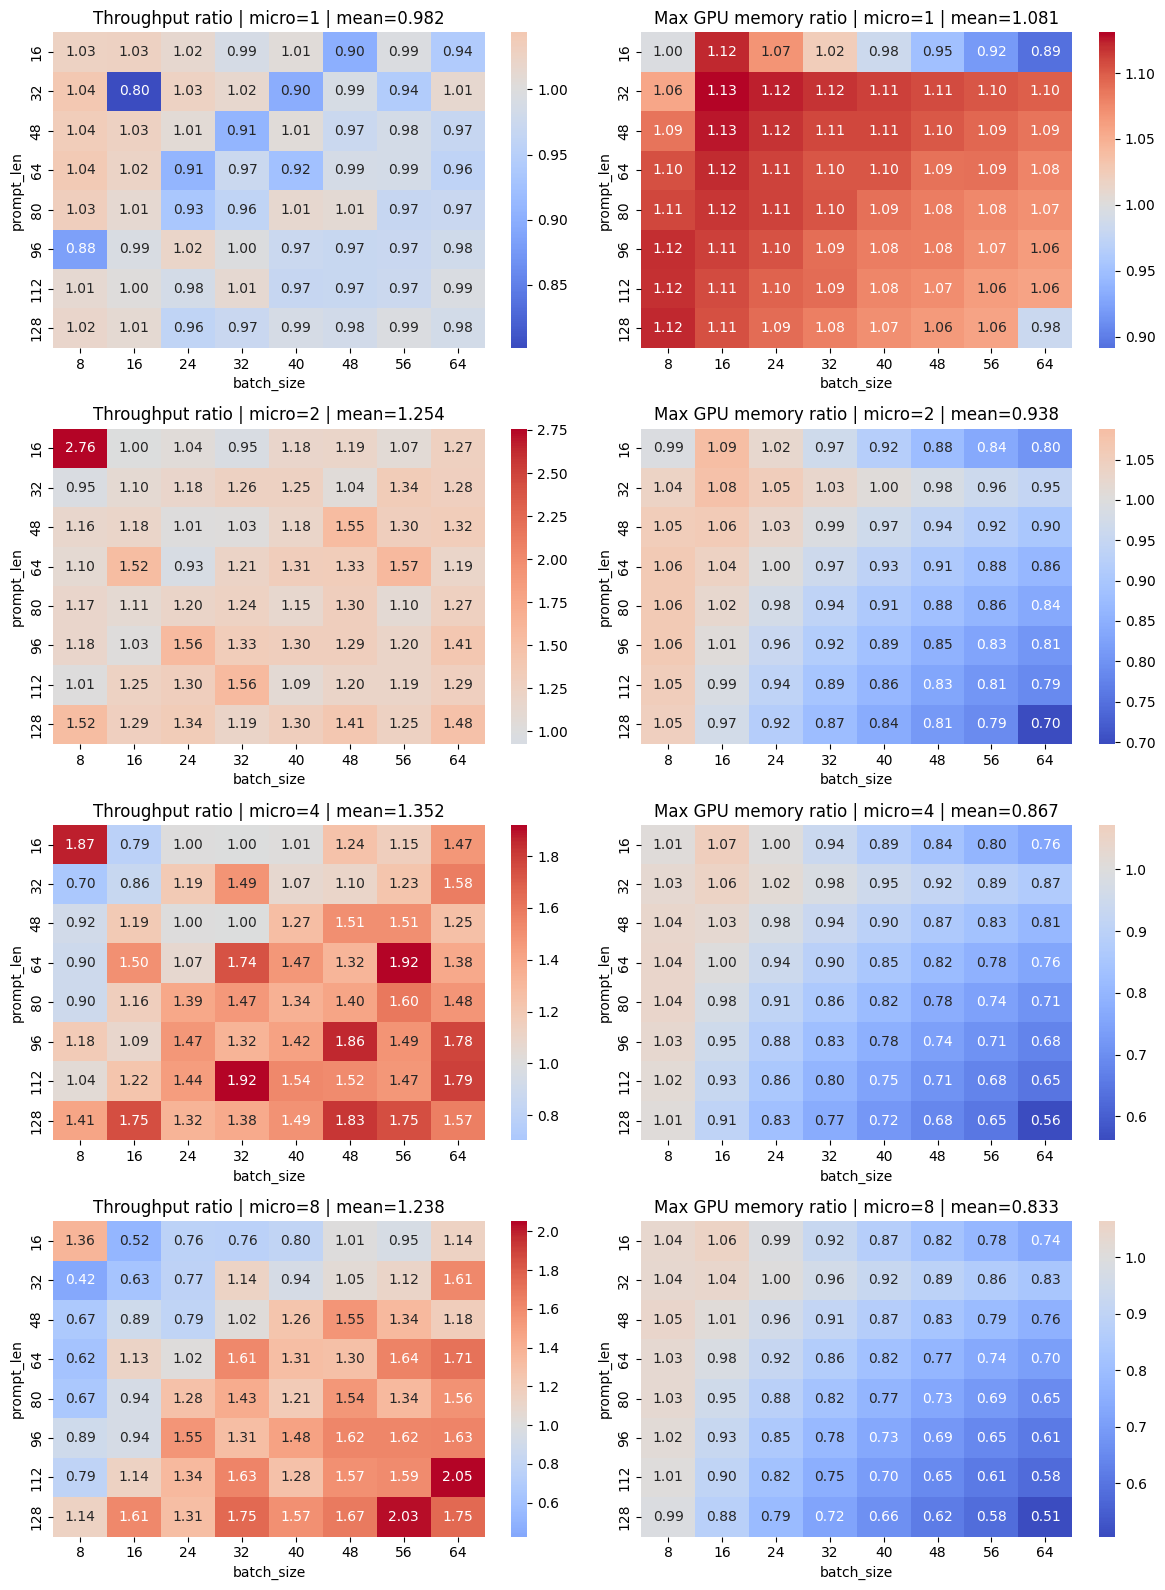

In [14]:
num_microbatches_list = sorted(df_2['num_microbatches'].unique())

# создаём фигуру: N рядов = количество num_microbatches, 2 столбца (Throughput, Memory)
fig, axes = plt.subplots(len(num_microbatches_list), 2, figsize=(12, 4 * len(num_microbatches_list)))

if len(num_microbatches_list) == 1:
    axes = np.array([[axes[0], axes[1]]])  # корректируем на 2D массив axes

for idx, micro in enumerate(num_microbatches_list):
    
    # --- df_2: фиксируем num_microbatches ---
    df2_micro = df_2[df_2['num_microbatches'] == micro].copy()
    best_idx = df2_micro.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
    best_data2 = df2_micro.loc[best_idx].copy()
    best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)
    
    # --- df_1: среднее по всем num_microbatches для каждой комбинации prompt_len и batch_size ---
    df1_group = df_1.groupby(['prompt_len', 'batch_size']).mean().reset_index()
    df1_group['max_gpu'] = df1_group[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)
    
    # --- pivot tables ---
    pivot_thr_df2 = best_data2.pivot_table(values='throughput (tokens/s)', index='prompt_len', columns='batch_size')
    pivot_thr_df1 = df1_group.pivot_table(values='throughput (tokens/s)', index='prompt_len', columns='batch_size')
    
    pivot_mem_df2 = best_data2.pivot_table(values='max_gpu', index='prompt_len', columns='batch_size')
    pivot_mem_df1 = df1_group.pivot_table(values='max_gpu', index='prompt_len', columns='batch_size')
    
    # --- ratios ---
    ratio_thr = pivot_thr_df2 / pivot_thr_df1
    ratio_mem = pivot_mem_df2 / pivot_mem_df1
    
    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)
    
    # --- plotting ---
    sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"Throughput ratio | micro={micro} | mean={mean_ratio_thr:.3f}")
    axes[idx, 0].set_xlabel("batch_size")
    axes[idx, 0].set_ylabel("prompt_len")
    
    sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[idx, 1])
    axes[idx, 1].set_title(f"Max GPU memory ratio | micro={micro} | mean={mean_ratio_mem:.3f}")
    axes[idx, 1].set_xlabel("batch_size")
    axes[idx, 1].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()